In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import normalize
from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray

In [16]:
path = "project_data/training_set/"
csv_data = "project_data/training_set.csv"

In [64]:
data_complet = pd.read_csv(csv_data)

In [65]:
data_complet.head()

,id,labels,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,y_58,y_59,y_60,y_61,y_62,y_63,y_64,y_65,y_66,y_67
0,27611.jpg,sad,385.9,388.4,395.6,409.1,431.0,463.7,502.2,546.4,...,570.1,569.3,558.0,545.9,545.5,541.5,545.7,540.8,545.4,545.7
1,84606.jpg,surprise,434.3,435.5,440.8,450.6,466.7,491.1,518.8,554.2,...,571.4,555.4,522.6,503.7,504.9,505.6,527.7,548.8,549.4,546.7
2,18271.jpg,neutral,286.5,289.7,296.7,306.2,322.7,349.4,384.3,426.6,...,566.6,564.8,555.0,550.0,549.9,547.2,547.1,546.4,548.2,548.0
3,43432.jpg,fear,261.3,264.2,271.7,282.0,299.3,326.8,360.0,397.7,...,509.5,502.0,478.6,468.8,469.3,465.5,470.5,484.9,488.4,487.6
4,25455.jpg,anger,309.3,312.9,321.9,333.8,352.1,379.4,408.7,445.2,...,590.4,583.9,569.5,563.8,564.6,561.9,563.8,562.9,565.4,564.0


# ID extermination
## doublon dans les id
155/305  
155 il n'est pas sur le visage  
  
338/382  
338 n'est pas sur le visage  
  
248/502  
248 n'est pas sur le visage  
  
431/587  
431 n'est pas sur le visage  
  
528/975  
528 n'est pas sur le visage  
  
661/867  
661 n'est pas sur le visage  

In [80]:
anihiler_les_doublons = [155, 338, 248, 431, 528, 661]
data = data_complet.drop(index=anihiler_les_doublons)
data.reset_index(drop=True, inplace=True)


nom = data['id']
label = data['labels']
point = data.drop(['id', 'labels'], axis=1)
point_x = data.filter(like='x')
point_y = data.filter(like='y')

In [132]:
point_x_normalize = normalize(point_x)
point_y_normalize = normalize(point_y)
point_normalize = normalize(point)

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Columns: 138 entries, id to  y_67
dtypes: float64(136), object(2)
memory usage: 1.0+ MB


In [82]:
print(nom[155])
print(nom[305])

14254.jpg
54413.jpg


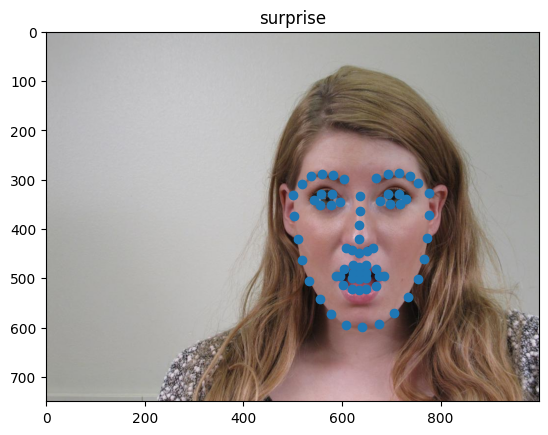

In [84]:
indice_img = 530
img = mpimg.imread(path + nom[indice_img])
plt.imshow(img)
plt.scatter(point_x.iloc[indice_img], point_y.iloc[indice_img])
plt.title(label[indice_img])
plt.show()

In [85]:
def emotion_accuracy(y_test, y_pred):
    dico = {'sad':[], 'surprise':[], 'neutral':[], 'fear':[], 'anger':[], 'disgust':[], 'happy':[]}
    for t, p in zip(y_test, y_pred):
        if t == p:
            dico[t].append(1)
        else:
            dico[t].append(0)

    for k, v in dico.items():
        dico[k] = sum(v) / len(v) * 100

    # plt.bar(dico.keys(), dico.values())
    # plt.show()

    return dico



In [116]:
jernel = ['linear', 'poly', 'rbf']
C = [1, 10, 100, 1000]
emotion = ['sad', 'surprise', 'neutral', 'fear', 'anger', 'disgust', 'happy']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(point_normalize, label, test_size=0.2, random_state=42)

dico_em = {k:[] for k in jernel}


param = {'kernel':('poly', 'rbf'), 'C':[i for i in range(1, 100, 5)], 
         'gamma':[i/100 for i in range(10, 60, 5)], 
         'degree':[2, 3, 4, 5]
          }

for k in jernel:
  print(f'\n\n\n{k}')
  for c in [1, 10, 100, 1000]:
    clf = svm.SVC(kernel=k, C=c)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Précision du modèle : {accuracy * 100:.2f}%")

    dico = emotion_accuracy(y_test, y_pred)
    print(dico)

    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()
    plt.show()

    plt.bar(dico.keys(), dico.values())
    plt.title(f'{k} avec C = {c}')
    plt.show()

#svc = svm.SVC()
#clf = GridSearchCV(svc, param, scoring='accuracy')
#clf.fit(X_train, y_train)

In [158]:
print(clf.best_params_)

{'C': 96, 'degree': 2, 'gamma': 0.55, 'kernel': 'rbf'}


In [159]:
y_pred = clf.best_estimator_.predict(X_test)

# Évaluer la performance du modèle
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.47      0.50      0.48        14
     disgust       0.45      0.83      0.59        18
        fear       0.60      0.80      0.69        15
       happy       1.00      0.36      0.53        11
     neutral       0.00      0.00      0.00        11
         sad       0.43      0.46      0.44        13
    surprise       1.00      0.75      0.86        16

    accuracy                           0.57        98
   macro avg       0.56      0.53      0.51        98
weighted avg       0.57      0.57      0.54        98



/home/victor/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/victor/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/victor/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:


# dico_em[k].append(dico)
